TPs prog S8

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import time

In [2]:
def generer_liste(nb):
  return [random.randint(x,x*10) for x in range(nb)]

In [3]:
Liste = generer_liste(5)
Liste

[0, 4, 7, 13, 15]

Le tri par sélection consiste à chercher le plus petit élément de la liste et à le placer en première
position. Une fois le plus petit élément positionné en première position, on recommence la
même opération en commençant à la deuxième position de la liste : on cherche le plus petit
élément compris dans la liste entre la 2e position et la fin de la liste, puis on place cet élément
à la deuxième position. On recommence ainsi en partant de la 3e position, puis de la 4e et ainsi
de suite jusqu’au bout de la liste.

In [4]:
def bubble_sort(Liste):
  l = Liste
  for i in range(len(l)):
    for j in range(i,len(l)):
      if l[j]<l[i]:
        l[i],l[j] = l[j] , l[i]

  return l

def select_sort(Liste):
  l = Liste

  min = 0
  argmin = 0

  for i in range(len(l)):
    min = l[i]
    argmin = i
    for j in range(i,len(l)):
      if l[j]<min:
        min= l[j]
        argmin = j
      l[i] , l[argmin]  = l[argmin], l[i]

  return l





In [5]:
print(bubble_sort(Liste))



[0, 4, 7, 13, 15]


In [6]:
print(select_sort(Liste))

[0, 4, 7, 13, 15]


Le tri par insertion consiste à classer les deux premiers éléments de la liste. Une fois que les
deux premiers sont ordonnés, on prend l’élément qui suit et on le classe à son tour dans ce qui
a déjà été classé. Pour chaque élément i de la liste, on sait que les éléments positionnés aux
indices de 0 à i-1 sont déjà classés. On va chercher la position j parmi les i-1 premiers éléments
de manière à ce que L[i] < L[j]. On insère alors T[i] à la position j.
Ecrire la fonction trier_par_insertion qui prend en paramètre une liste et retourne cette même
liste triée par ordre croissant.

In [20]:
def insert_sort(L, start=0, end=None):
    if end is None: 
        end = len(L)
    for i in range(start + 1, end):
        k = L[i]
        j = i
        while j > start and L[j - 1] > k:
            L[j] = L[j - 1]
            j -= 1
        L[j] = k
    return L    

In [21]:
l = generer_liste(5)

print(insert_sort(l))

[0, 4, 7, 11, 19]


Le tri par fusion est un algorithme qui propose de :

• Découper la liste en 2 parties de longueur égale (à un élément près) ;

• Trier les deux sous listes ;

• Fusionner ces deux sous listes triées pour n’en former qu’une seule qui soit elle-même
triée.

Avant de réaliser la fonction de tri en elle-même, écrire une fonction fusionner_listes qui prend
en paramètres 2 listes triées et retourne une liste triée issue de la fusion des deux listes passées
en paramètres.
Ecrire la fonction trier_par_fusion qui prend en paramètre une liste et retourne cette même
liste triée par ordre croissant.

In [9]:
def quick_sort(l):
  if len(l)<=1:
    return l


  centre = len(l)//2
  pivot = l[centre]


  gauche = []
  middle = []
  droite = []


  for el in l:
    if el > pivot:
      droite.append(el)
    elif el == pivot:
      middle.append(el)
    else:
      gauche.append(el)
  return quick_sort(gauche) + middle + quick_sort(droite)

In [10]:
n = 5
n >> 1


2

In [30]:
def minrun_length(n):
    r = 0
    while n >= 64:
        r |= n & 1
        n >>= 1
    return n + r


def insert_sort_2(L, start=0, end=None):
    if end is None:
        end = len(L)

    for i in range(start + 1, end):
        k = L[i]
        j = i
        while j > start and L[j - 1] > k:
            L[j] = L[j - 1]
            j -= 1
        L[j] = k


def detect_run(a, start, end):
    """
    Détecte un run naturel à partir de start.
    Si le run est décroissant, on l'inverse pour le rendre croissant.
    Retourne la longueur du run.
    """
    i = start + 1
    if i >= end:
        return 1

    # Run décroissant
    if a[i] < a[start]:
        while i < end and a[i] < a[i - 1]:
            i += 1
        a[start:i] = reversed(a[start:i])
    else:
        # Run croissant (non décroissant)
        while i < end and a[i] >= a[i - 1]:
            i += 1

    return i - start


def make_runs(a):
    """
    Découpe a en runs (segments triés).
    Force une taille minimale minRun via insertion sort si besoin.
    Renvoie la liste de tuples (lo, hi) (hi exclu).
    """
    n = len(a)
    if n <= 1:
        return [(0, n)]

    minRun = minrun_length(n)
    runs = []
    i = 0

    while i < n:
        run_len = detect_run(a, i, n)

        if run_len < minRun:
            force = min(minRun, n - i)
            insert_sort_2(a, i, i + force)
            run_len = force

        runs.append((i, i + run_len))
        i += run_len

    return runs


def fusion_2(l1, l2):
    """
    Fusionne 2 listes triées (l1, l2) et renvoie une nouvelle liste triée.
    """
    i = j = 0
    res = []

    while i < len(l1) and j < len(l2):
        if l1[i] <= l2[j]:
            res.append(l1[i])
            i += 1
        else:
            res.append(l2[j])
            j += 1

    res.extend(l1[i:])
    res.extend(l2[j:])
    return res


def merge_runs(a, lo, mid, hi):
    """
    Fusionne a[lo:mid] et a[mid:hi] (déjà triés) dans a[lo:hi].
    """
    a[lo:hi] = fusion_2(a[lo:mid], a[mid:hi])


def merge_all_runs(a, runs):
    """
    Fusionne tous les runs jusqu'à n'en garder qu'un.
    """
    while len(runs) > 1:
        new_runs = []
        i = 0

        while i < len(runs):
            if i + 1 == len(runs):
                new_runs.append(runs[i])
                break

            lo1, hi1 = runs[i]
            lo2, hi2 = runs[i + 1]

            # En principe: hi1 == lo2 (runs consécutifs)
            merge_runs(a, lo1, hi1, hi2)
            new_runs.append((lo1, hi2))
            i += 2

        runs = new_runs

    return a


def timsort(a):
    runs = make_runs(a)
    return merge_all_runs(a, runs)

Merge sort 

In [ ]:
def merge_sort(l):
  if len(l)<=1:
    return l

  middle = len(l) // 2

  left = merge_sort(l[:middle])
  right = merge_sort(l[middle:])

  return fusion_2(left,right)

In [33]:
l = generer_liste(100000)
print(timsort(l))

[0, 6, 8, 11, 15, 17, 18, 18, 22, 24, 31, 32, 36, 36, 38, 41, 47, 51, 61, 61, 62, 66, 66, 69, 71, 81, 83, 83, 86, 89, 98, 105, 108, 109, 119, 120, 128, 132, 133, 152, 152, 157, 169, 174, 179, 185, 185, 193, 200, 200, 206, 209, 210, 213, 216, 216, 219, 230, 231, 242, 247, 247, 255, 256, 272, 276, 279, 284, 285, 285, 295, 308, 314, 317, 319, 319, 322, 324, 333, 339, 339, 343, 354, 356, 359, 363, 364, 367, 370, 371, 372, 379, 379, 379, 384, 384, 386, 389, 389, 389, 396, 397, 398, 401, 418, 421, 425, 425, 429, 432, 436, 436, 440, 443, 454, 463, 464, 482, 484, 486, 489, 495, 495, 495, 496, 501, 504, 504, 511, 522, 525, 529, 533, 544, 550, 552, 553, 556, 561, 568, 568, 583, 587, 589, 589, 591, 594, 601, 601, 607, 608, 611, 613, 618, 618, 618, 621, 633, 639, 646, 650, 656, 659, 661, 662, 665, 668, 674, 680, 680, 680, 682, 684, 687, 690, 693, 699, 713, 713, 722, 722, 723, 727, 729, 731, 731, 733, 740, 742, 747, 752, 755, 757, 758, 760, 772, 785, 792, 810, 813, 814, 819, 822, 824, 825, 826, 827

In [ ]:
l1 = generer_liste(20)

print(merge_sort(l1))

[0, 5, 7, 8, 12, 12, 20, 22, 24, 30, 37, 38, 40, 43, 52, 61, 71, 95, 138, 152]


bubble_sort: 0.018583666998893023 seconds
select_sort: 0.031067208998138085 seconds
insert_sort: 0.007867499996791594 seconds
quick_sort: 0.00141141600033734 seconds
merge_sort: 0.0015577079975628294 seconds
timsort: 0.0018601249976200052 seconds


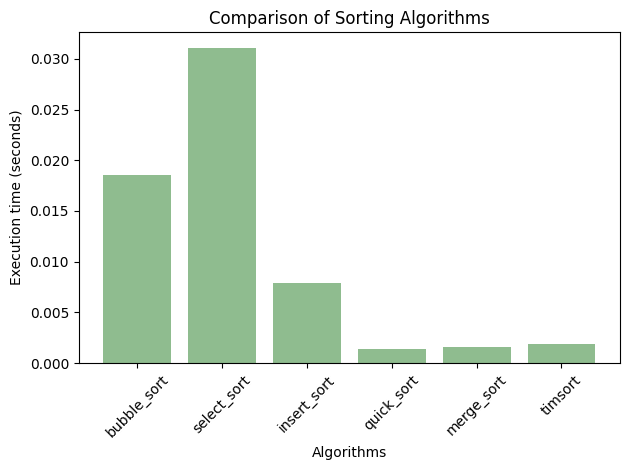

In [55]:
ltest = generer_liste(1000)


def benchmark(func, data):
    arr = data.copy()  # IMPORTANT : ne pas modifier la liste originale
    
    start = time.perf_counter()  # plus précis que time.time()
    func(arr)
    end = time.perf_counter()
    
    return end - start  

sort_functions = [bubble_sort, select_sort, insert_sort, quick_sort, merge_sort, timsort]

times = {}
for elem in sort_functions:
    times[elem.__name__] = benchmark(elem, ltest)

for k, v in times.items(): 
    print(f"{k}: {v} seconds")
df = pd.DataFrame(data=times , index=[0])
    

plt.figure()
plt.bar(times.keys(), times.values(), color='darkseagreen')
plt.xticks(rotation=45)
plt.xlabel("Algorithms")
plt.ylabel("Execution time (seconds)")
plt.title("Comparison of Sorting Algorithms")
plt.tight_layout()
plt.show()

